In [1]:
import seaborn as sns
import pandas as pd
from sklearn.metrics import confusion_matrix, f1_score
from datetime import datetime
from typing import List, Tuple
from matplotlib import pyplot as plt
from matplotlib.axes import Axes

from freeze_thaw.data_preparation.general import align_timestamps
from freeze_thaw.config import config as c
from freeze_thaw.config import StationName
from freeze_thaw.data_preparation.general import filter_df

# Assess Methodology

A key assumption in this project is that a single point measurement from an ISMN station can be used to benchmark an area measurement from space-based sensors. This may be a massive leap since the ASCAT and ERA5 measurements cover areas over 100 km$^2$. The goal of this notebook is to compare the ERA5 and ISMN soil temperature measurements to understand the difference between the two methods.

---

## Table of Contents

1. **Setup**
    - *1.1 Variables*
    - *1.2 Functions*
2. **ISMN Stations**
    - *2.1 Aberdeen-35-WNW*
    - *2.2 Jamestown-38-WSW*
    - *2.3 Gobblers Knob*
    - *2.4 Nenana*
    - *2.5 L23*
    - *2.6 L38*
    - *2.7 NST-07*
    - *2.8 NST-09*
    - *2.9 SOD012*
    - *2.10 SOD103*
3. **Summary**
4. **Conclusions**
---

## 1. Setup

### 1.1 Variables

In [2]:
start_date = datetime(2015, 1, 1)
end_date = datetime(2016, 1, 1)
summary_df = pd.DataFrame(columns=["Station", "Macro F1", "Transition F1"])

### 1.2 Functions

In [3]:
def create_cm_df(df: pd.DataFrame, classes: List[str]) -> pd.DataFrame:
    """
    Output sklearn confusion matrix.
    :param df: cleaned and combined data df with "pred" and "class" columns
    :param classes: class labels
    :return: sklearn confusion matrix in the form of a df
    """
    if not {'class', 'pred'}.issubset(df.columns):
        raise ValueError("df must contain 'class' and 'pred' columns")
    if len(classes) != len(df['class'].unique()):
        raise ValueError("classes and df['class'].unique() must have same length")

    cm = confusion_matrix(df['class'], df['pred'], labels=classes)
    cm_df = pd.DataFrame(cm, index=c.CLASSES, columns=c.CLASSES)

    return cm_df

def transition_f1(actual: pd.Series, pred: pd.Series, class_labels: Tuple[str, str, str]) -> float:
    """
    Assummed that the transition class is in position 1 of class_labels.
    :param actual: Labels according to ISMN data
    :param pred: Predicted labels according to ERA5 data
    :param class_labels: class labels
    :return: f1 score for transition class
    """
    f1_per_class = f1_score(
        actual,
        pred,
        average=None,
        labels=class_labels,
    )

    return f1_per_class[1]

def calculate_f1_scores(df: pd.DataFrame, class_labels: Tuple[str, str, str]) -> Tuple[float, float]:
    """
    Calculate f1 scores for reporting
    :param df: cleaned and combined data df with "pred" and "class" columns
    :param class_labels: class labels
    :return: macro_f1_score, transition_f1_score
    """
    actual = df['class']
    pred = df['pred']

    macro_f1_score = round(f1_score(actual, pred, average="macro"), 3)
    transition_f1_score = round(transition_f1(actual, pred, class_labels), 3)

    return macro_f1_score, transition_f1_score

def plot_temp_labels(df: pd.DataFrame, name: StationName, start: datetime, end: datetime) -> Axes:
    """
    Plots scatterplot of ERA5 stl1 vs time with datapoints colored by class label according to ISMN data.
    :param df: cleaned and combined data df
    :param name: station name
    :param start: naive datetime.datetime object (inclusive)
    :param end: naive datetime.datetime object (inclusive)
    :return: matplotlib Axes object
    """
    if not {'class', 'stl1'}.issubset(df.columns):
        raise ValueError("df must contain 'class' and 'stl1' columns")
    if not df.index.inferred_type == "datetime64":
        raise ValueError("df index inferred_type must be datetime64")

    df_copy = df.copy()
    df_copy = filter_df(df_copy, start, end)

    palette = {
        c.CLASSES[0]: "tab:blue",
        c.CLASSES[1]: "tab:brown",
        c.CLASSES[2]: "tab:green",
    }

    ax = sns.scatterplot(data=df_copy, x=df_copy.index.name, y='stl1',
                         hue='class', palette=palette
                         )
    ax.set_title(name)
    ax.set_ylabel("ERA5 stl1 (\u00B0C)")
    ax.set_xlabel("Timestamp")

    return ax

def plot_temp_differences(df: pd.DataFrame, name: StationName, start: datetime, end: datetime) -> tuple[Axes, Axes]:
    """
    Creates two plots. The first is a line plot of both the measured soil temperatures according to both methods.
    The second plot is a line plot that shows the difference between the ISMN and ERA5 soil temperatures.
    :param df: cleaned and combined data df
    :param name: station name
    :param start: naive datetime.datetime object (inclusive)
    :param end: naive datetime.datetime object (inclusive)
    :return: two matplotlib Axes objects
    """

    if not {'soil_temp', 'stl1'}.issubset(df.columns):
        raise ValueError("df must contain 'soil_temp' and 'stl1' columns")
    if not df.index.inferred_type == "datetime64":
        raise ValueError("df index inferred_type must be datetime64")

    df_copy = df.copy()
    df_copy = filter_df(df_copy, start, end)

    diff = df_copy["soil_temp"] - df_copy["stl1"]

    fig, (ax1, ax2) = plt.subplots(
        2, 1,
        figsize=(12, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # Top panel
    ax1.plot(df_copy.index, df_copy["stl1"], label="ERA5")
    ax1.plot(df_copy.index, df_copy["soil_temp"], label="ISMN")
    ax1.legend()
    ax1.set_title(name)
    ax1.set_ylabel("Temperature (\u00B0C)")
    ax1.grid(alpha=0.3)

    # Bottom panel
    ax2.plot(df_copy.index, diff, color="tab:red")
    ax2.axhline(0, color="black", ls="--", lw=1)
    ax2.set_ylabel("Difference (ISMN-ERA5)")
    ax2.set_xlabel("Timestamp")
    ax2.grid(alpha=0.3)

    return ax1, ax2

## 2. ISMN Stations

### 2.1 Aberdeen-35-WNW

In [4]:
_, aberdeen_era5_df = align_timestamps(StationName.ABERDEEN, c.CLEANED_DATA_PATH)
aberdeen_era5_df = aberdeen_era5_df.dropna()

aberdeen_macro_f1, aberdeen_transition_f1 = calculate_f1_scores(aberdeen_era5_df, c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.ABERDEEN, aberdeen_macro_f1, aberdeen_transition_f1]

create_cm_df(aberdeen_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,2063,319,4
transition,1723,912,477
thawed,401,388,9671


<Axes: title={'center': 'Aberdeen-35-WNW'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

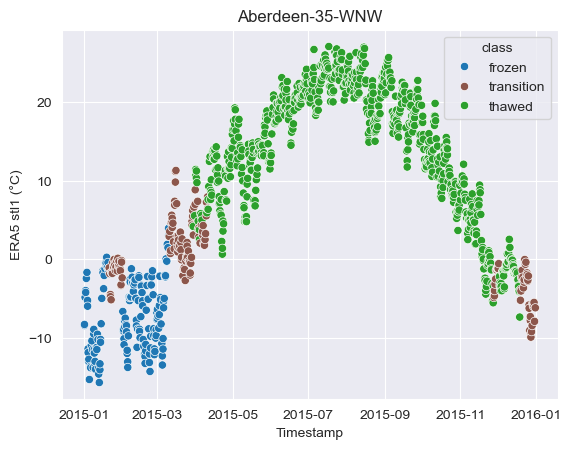

In [5]:
plot_temp_labels(aberdeen_era5_df, StationName.ABERDEEN, start_date, end_date)

(<Axes: title={'center': 'Aberdeen-35-WNW'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

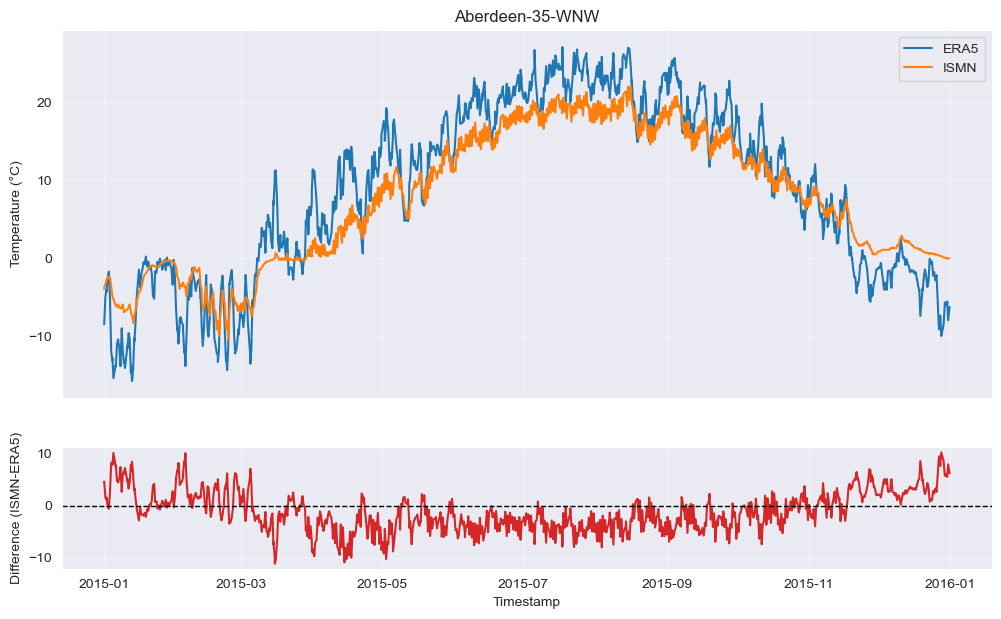

In [6]:
plot_temp_differences(aberdeen_era5_df, StationName.ABERDEEN, start_date, end_date)

### 2.2 Jamestown-38-WSW

In [7]:
_, jamestown_era5_df = align_timestamps(StationName.JAMESTOWN, c.CLEANED_DATA_PATH)
jamestown_era5_df = jamestown_era5_df.dropna()

jamestown_macro_f1, jamestown_transition_f1 = calculate_f1_scores(jamestown_era5_df, c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.JAMESTOWN, jamestown_macro_f1, jamestown_transition_f1]

create_cm_df(jamestown_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,2294,506,14
transition,1623,760,559
thawed,426,366,9460


In [8]:
create_cm_df(jamestown_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,2294,506,14
transition,1623,760,559
thawed,426,366,9460


<Axes: title={'center': 'Jamestown-38-WSW'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

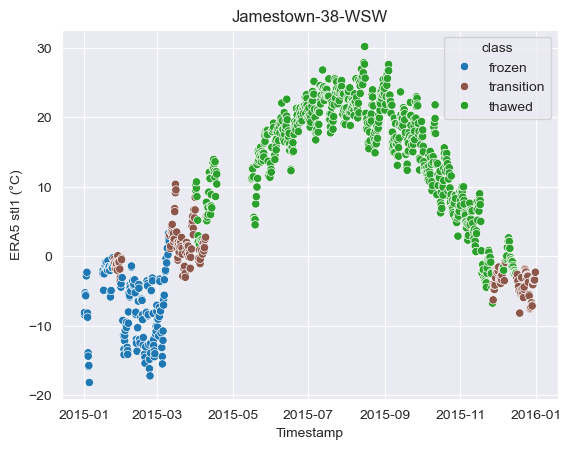

In [9]:
plot_temp_labels(jamestown_era5_df, StationName.JAMESTOWN, start_date, end_date)

(<Axes: title={'center': 'Jamestown-38-WSW'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

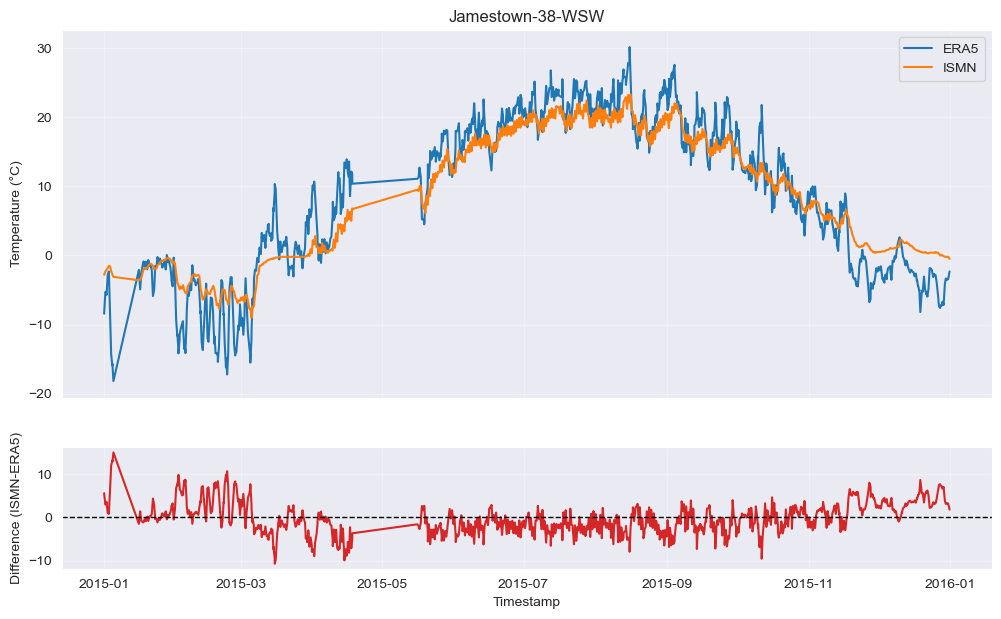

In [10]:
plot_temp_differences(jamestown_era5_df, StationName.JAMESTOWN, start_date, end_date)

### 2.3 Gobblers Knob

In [11]:
_, gobblers_knob_era5_df = align_timestamps(StationName.GOBBLERS_KNOB, c.CLEANED_DATA_PATH)
gobblers_knob_era5_df = gobblers_knob_era5_df.dropna()

gobblers_knob_macro_f1, gobblers_knob_transition_f1 = calculate_f1_scores(gobblers_knob_era5_df, c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.GOBBLERS_KNOB, gobblers_knob_macro_f1, gobblers_knob_transition_f1]

create_cm_df(gobblers_knob_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,14793,2576,4
transition,1959,2166,703
thawed,42,269,12743


<Axes: title={'center': 'GobblersKnob'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

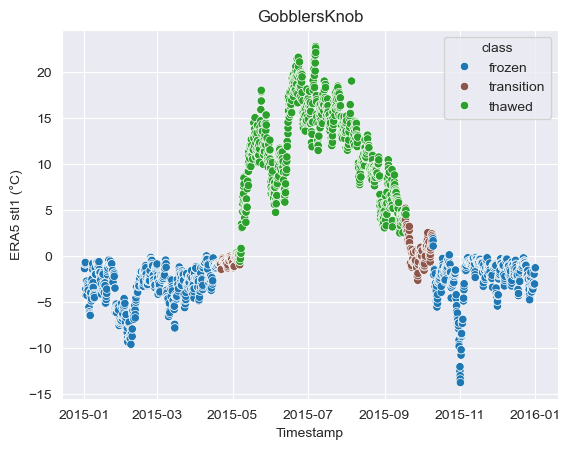

In [12]:
plot_temp_labels(gobblers_knob_era5_df, StationName.GOBBLERS_KNOB, start_date, end_date)

(<Axes: title={'center': 'GobblersKnob'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

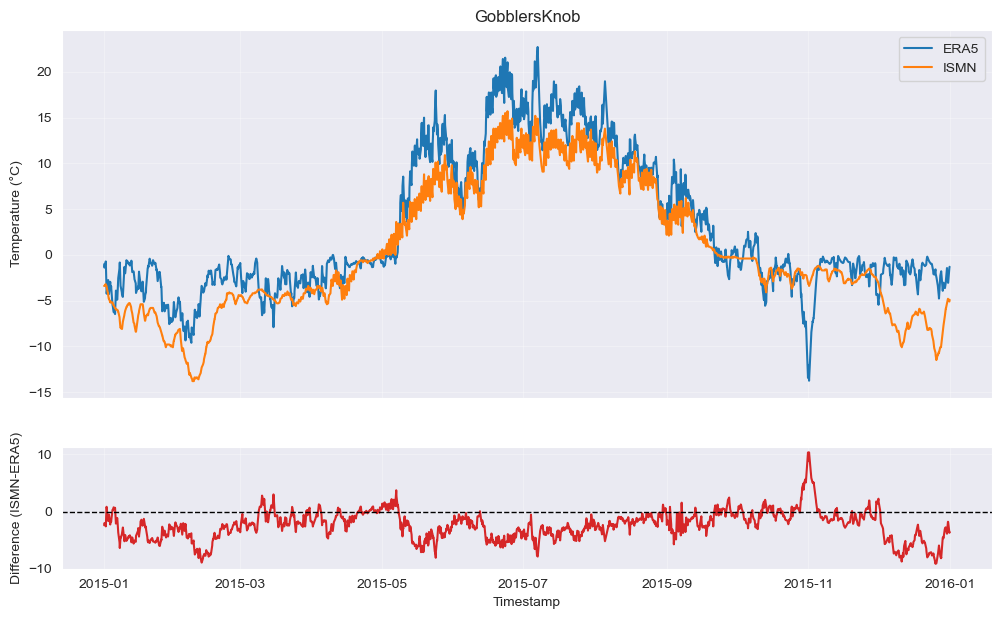

In [13]:
plot_temp_differences(gobblers_knob_era5_df, StationName.GOBBLERS_KNOB, start_date, end_date)

### 2.4 Nenana

In [14]:
_, nenana_era5_df = align_timestamps(StationName.NENANA, c.CLEANED_DATA_PATH)
nenana_era5_df = nenana_era5_df.dropna()

nenana_macro_f1, nenana_transition_f1 = calculate_f1_scores(nenana_era5_df, c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.NENANA, nenana_macro_f1, nenana_transition_f1]

create_cm_df(nenana_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,8169,624,21
transition,2359,1196,1246
thawed,160,204,9882


<Axes: title={'center': 'Nenana'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

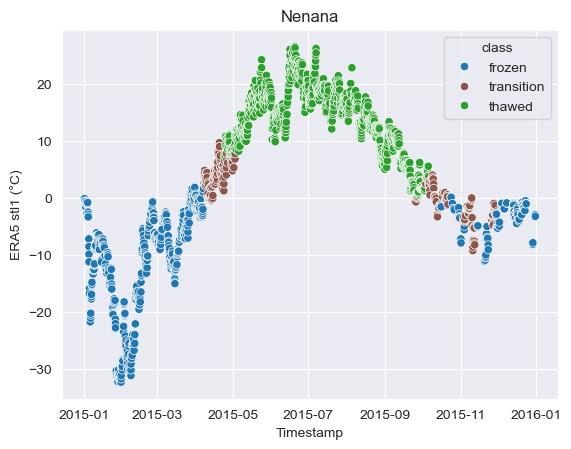

In [15]:
plot_temp_labels(nenana_era5_df, StationName.NENANA, start_date, end_date)

(<Axes: title={'center': 'Nenana'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

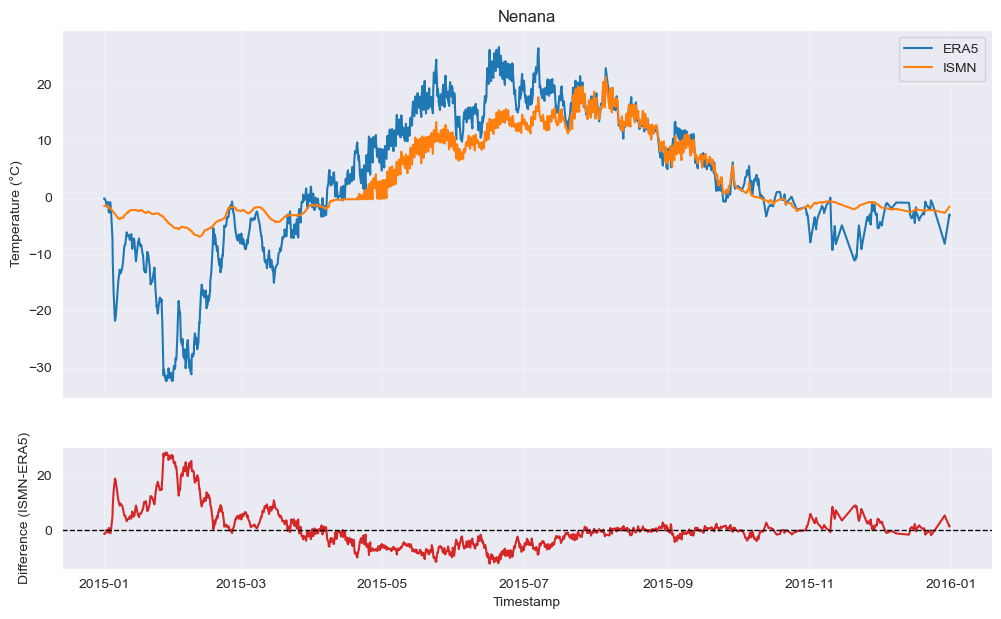

In [16]:
plot_temp_differences(nenana_era5_df, StationName.NENANA, start_date, end_date)

## 2.5 L23

In [17]:
_, L23_era5_df = align_timestamps(StationName.L23, c.CLEANED_DATA_PATH)
L23_era5_df = L23_era5_df.dropna()

L23_macro_f1, L23_transition_f1 = calculate_f1_scores(L23_era5_df, c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.L23, L23_macro_f1, L23_transition_f1]

create_cm_df(L23_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,1389,0,0
transition,560,20,0
thawed,287,247,1723


<Axes: title={'center': 'L23'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

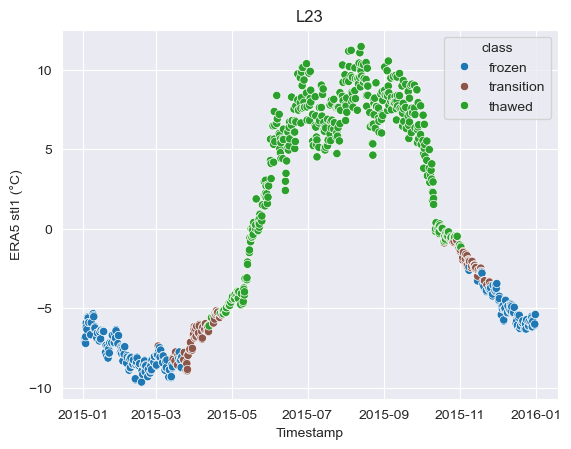

In [18]:
plot_temp_labels(L23_era5_df, StationName.L23, start_date, end_date)

(<Axes: title={'center': 'L23'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

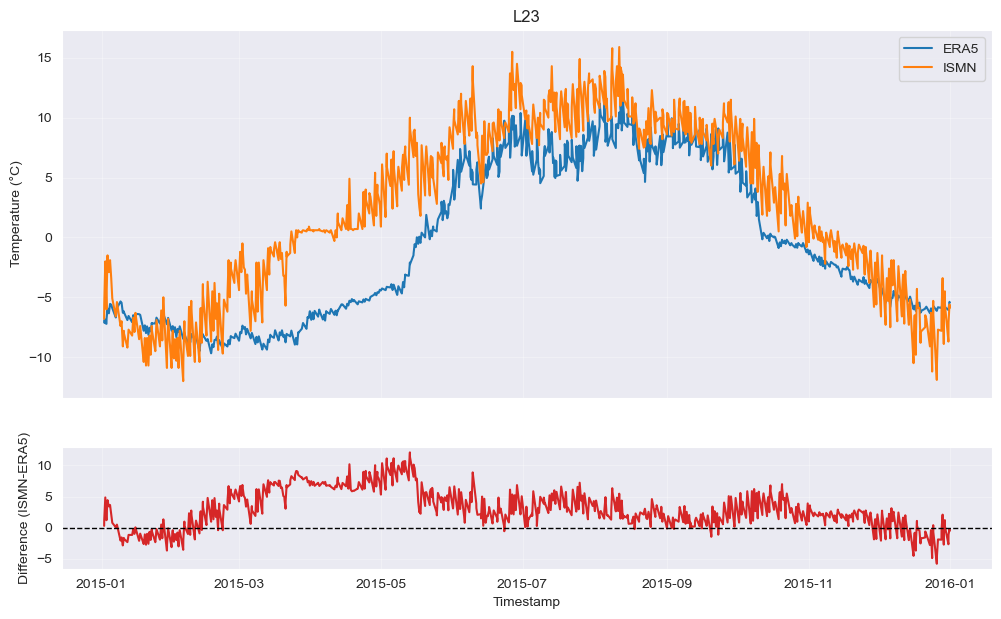

In [19]:
plot_temp_differences(L23_era5_df, StationName.L23, start_date, end_date)

### 2.6 L38

In [20]:
_, L38_era5_df = align_timestamps(StationName.L38, c.CLEANED_DATA_PATH)
L38_era5_df = L38_era5_df.dropna()

L38_macro_f1, L38_transition_f1 = calculate_f1_scores(L38_era5_df, c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.L38, L38_macro_f1, L38_transition_f1]

create_cm_df(L38_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,1186,0,0
transition,509,15,0
thawed,380,315,1847


<Axes: title={'center': 'L38'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

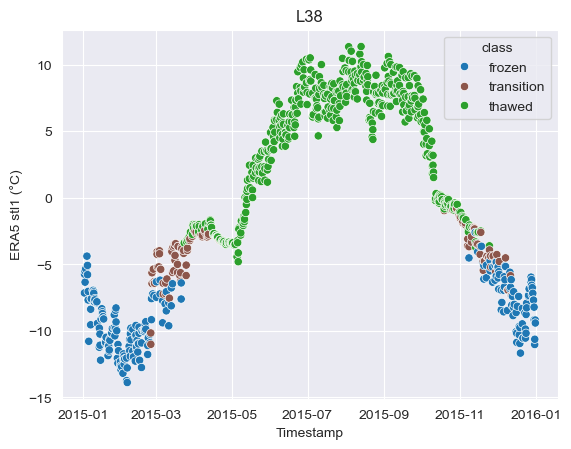

In [21]:
plot_temp_labels(L38_era5_df, StationName.L38, start_date, end_date)

(<Axes: title={'center': 'L38'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

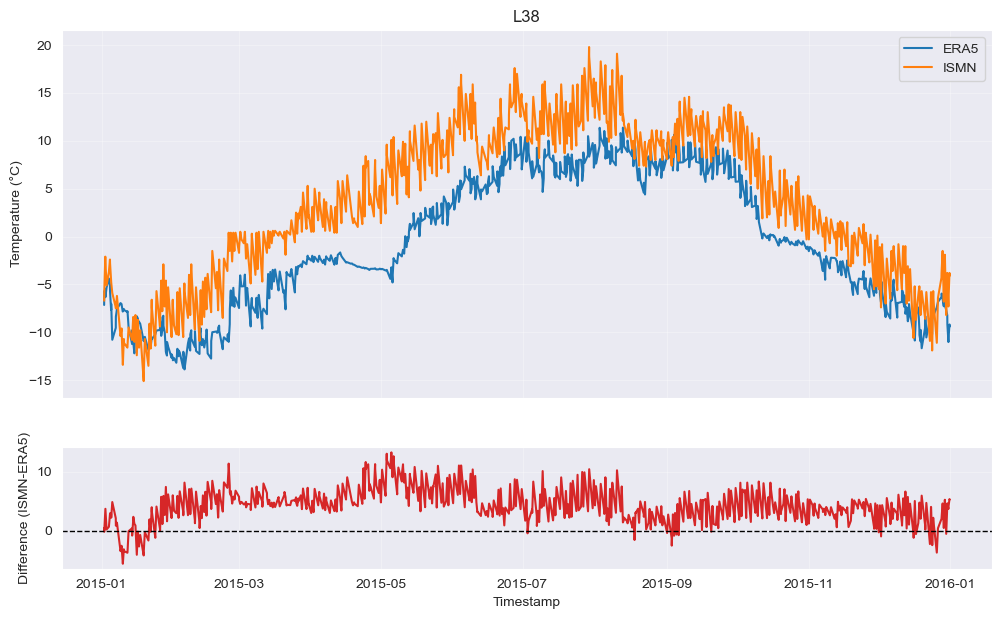

In [22]:
plot_temp_differences(L38_era5_df, StationName.L38, start_date, end_date)

## 2.7 NST-07

In [23]:
_, NST_07_era5_df = align_timestamps(StationName.NST_07, c.CLEANED_DATA_PATH)
NST_07_era5_df = NST_07_era5_df.dropna()

NST_07_macro_f1, NST_07_transition_f1 = calculate_f1_scores(NST_07_era5_df, c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.NST_07, NST_07_macro_f1, NST_07_transition_f1]

create_cm_df(NST_07_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,1323,0,0
transition,612,289,24
thawed,95,242,3288


<Axes: title={'center': 'NST-07'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

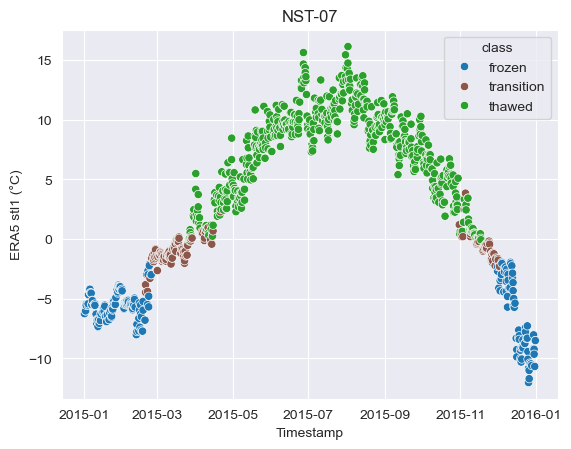

In [24]:
plot_temp_labels(NST_07_era5_df, StationName.NST_07, start_date, end_date)

(<Axes: title={'center': 'NST-07'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

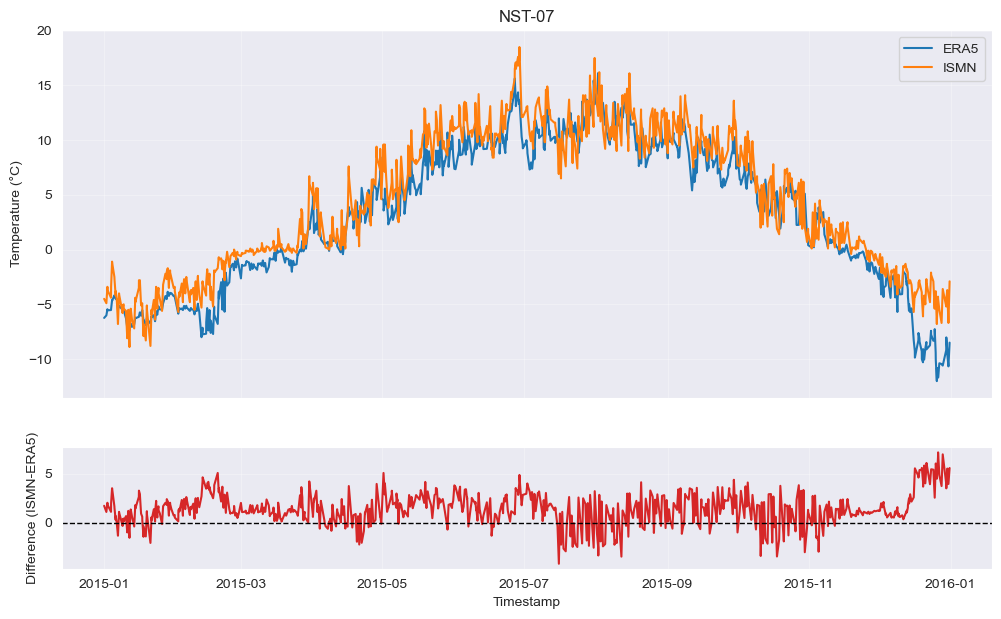

In [25]:
plot_temp_differences(NST_07_era5_df, StationName.NST_07, start_date, end_date)

### 2.8 NST-09

In [26]:
_, NST_09_era5_df = align_timestamps(StationName.NST_09, c.CLEANED_DATA_PATH)
NST_09_era5_df = NST_09_era5_df.dropna()

NST_09_macro_f1, NST_09_transition_f1 = calculate_f1_scores(NST_09_era5_df, c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.NST_09, NST_09_macro_f1, NST_09_transition_f1]

create_cm_df(NST_09_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,1533,5,0
transition,655,162,6
thawed,185,397,3259


<Axes: title={'center': 'NST-09'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

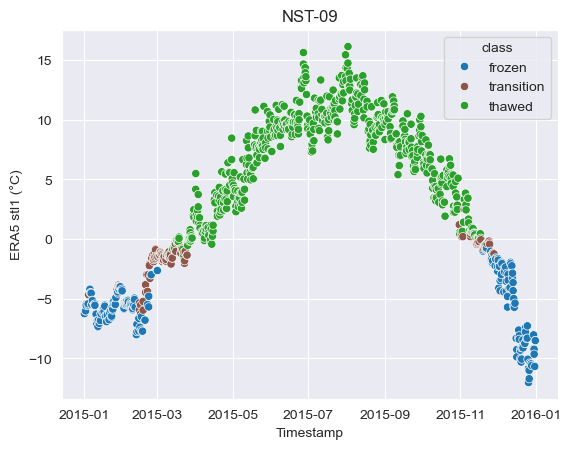

In [27]:
plot_temp_labels(NST_09_era5_df, StationName.NST_09, start_date, end_date)

(<Axes: title={'center': 'NST-09'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

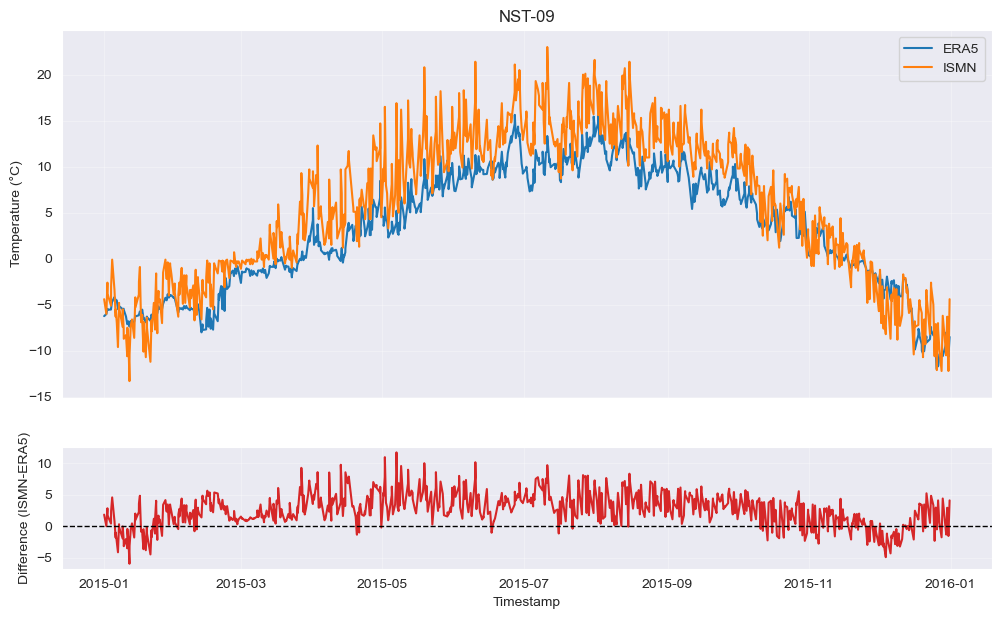

In [28]:
plot_temp_differences(NST_09_era5_df, StationName.NST_09, start_date, end_date)

### 2.9 SOD012

In [29]:
_, SOD012_era5_df = align_timestamps(StationName.SOD012, c.CLEANED_DATA_PATH)
SOD012_era5_df = SOD012_era5_df.dropna()

SOD012_macro_f1, SOD012_transition_f1 = calculate_f1_scores(SOD012_era5_df, c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.SOD012, SOD012_macro_f1, SOD012_transition_f1]

create_cm_df(SOD012_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,4022,821,0
transition,7461,4186,560
thawed,536,643,12117


<Axes: title={'center': 'SOD012'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

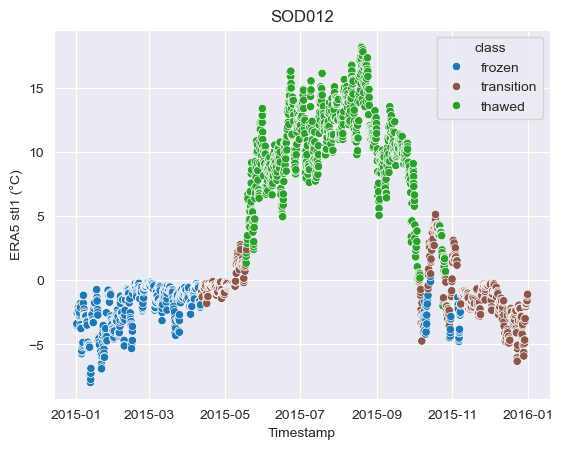

In [30]:
plot_temp_labels(SOD012_era5_df, StationName.SOD012, start_date, end_date)

(<Axes: title={'center': 'SOD012'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

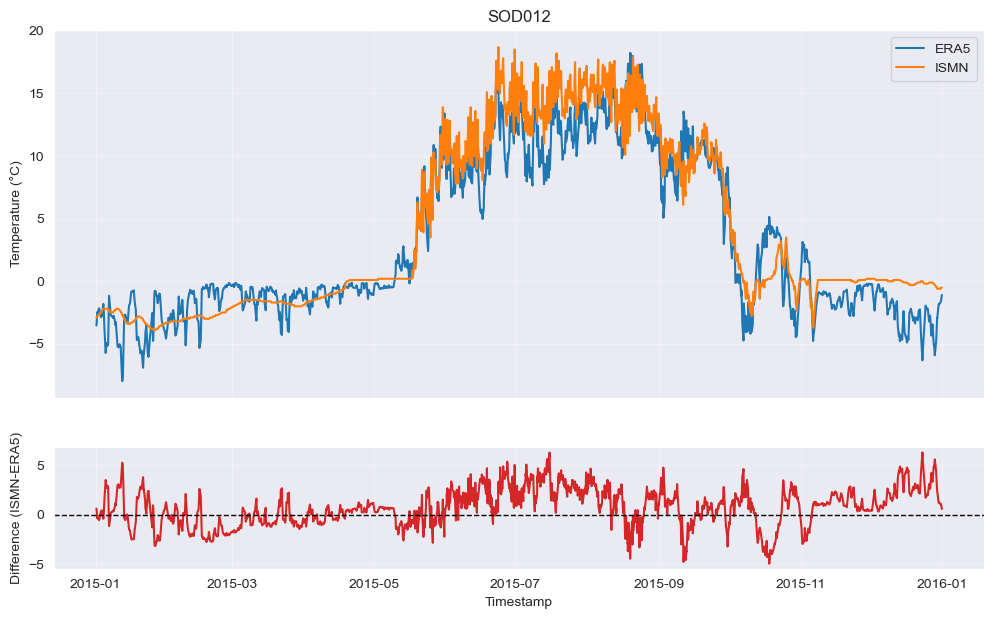

In [31]:
plot_temp_differences(SOD012_era5_df, StationName.SOD012, start_date, end_date)

### 2.10 SOD103

In [32]:
_, SOD103_era5_df = align_timestamps(StationName.SOD103, c.CLEANED_DATA_PATH)
SOD103_era5_df = SOD103_era5_df.dropna()

SOD0103_macro_f1, SOD0103_transition_f1 = calculate_f1_scores(SOD103_era5_df, c.CLASSES)

summary_df.loc[len(summary_df)] = [StationName.SOD103, SOD0103_macro_f1, SOD0103_transition_f1]

create_cm_df(SOD103_era5_df, c.CLASSES)

,frozen,transition,thawed
frozen,519,2,0
transition,8866,3490,17
thawed,2354,2066,12481


<Axes: title={'center': 'SOD103'}, xlabel='Timestamp', ylabel='ERA5 stl1 (°C)'>

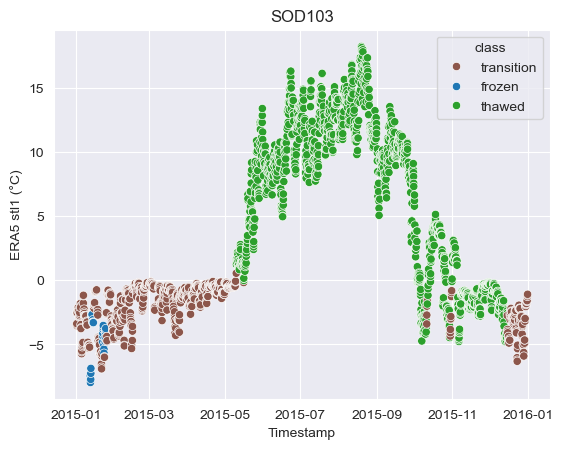

In [33]:
plot_temp_labels(SOD103_era5_df, StationName.SOD103, start_date, end_date)

(<Axes: title={'center': 'SOD103'}, ylabel='Temperature (°C)'>,
 <Axes: xlabel='Timestamp', ylabel='Difference (ISMN-ERA5)'>)

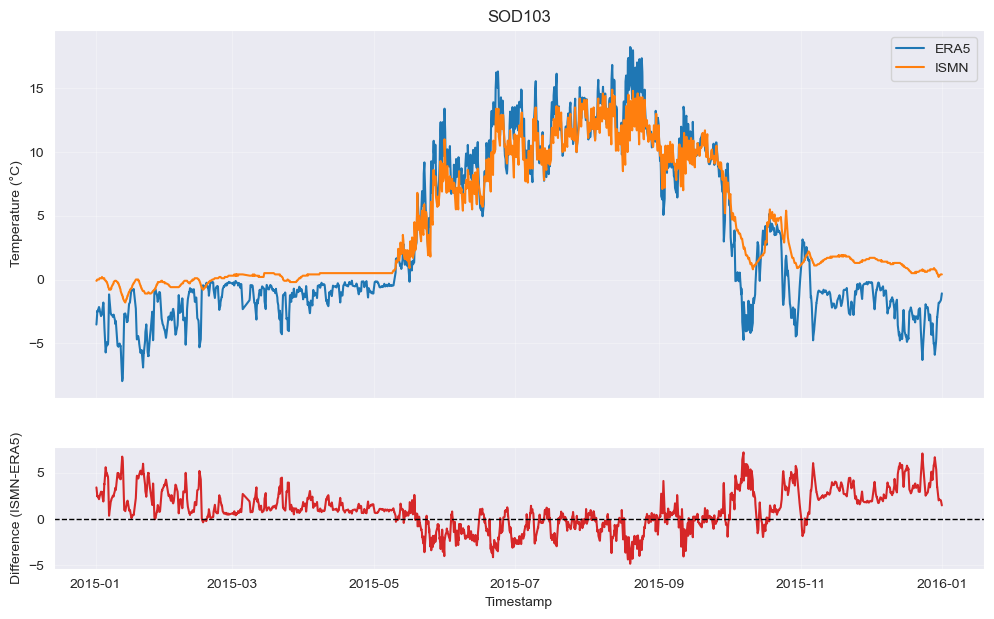

In [34]:
plot_temp_differences(SOD103_era5_df, StationName.SOD103, start_date, end_date)

## 3. Summary

In [40]:
summary_df.loc[len(summary_df)] = ["Average", summary_df["Macro F1"].mean(), summary_df["Transition F1"].mean()]
summary_df

,Station,Macro F1,Transition F1
0,Aberdeen-35-WNW,0.6510,0.3860
1,Jamestown-38-WSW,0.6350,0.3320
2,GobblersKnob,0.7560,0.4400
3,Nenana,0.7040,0.3500
4,L23,0.5600,0.0470
5,L38,0.5350,0.0350
6,NST-07,0.7110,0.3970
7,NST-09,0.6450,0.2340
8,SOD012,0.6260,0.4690
9,SOD103,0.4410,0.3890


## 4. Conclusions

Overall, ERA5 did not align with the ISMN stations in predicting transition states in the soil (between -1 and 1 &deg;C). It's only decent performance was for Gobbler's Knob. This appears to be due to large differences in the measured temperatures between the two methods, with differences reaching up to 20 &deg;C. In constrast, agreement is better for the frozen and thawed states since their definitions are more forgiving than the transition state.

The plots indicate that taking a single point measurement to compare against a large area measurement is not the most sound approach.